In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import pingouin as pg
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from matplotlib.lines import Line2D
import math
from statsmodels.stats.anova import anova_lm
import seaborn as sns

## Population pedigree consist

In [49]:
df_individuals = pd.read_excel('/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/doc/Figures/Cell_initial_submit/Table S3 GWAS behavioral data.xlsx',
                       sheet_name=0).dropna()

In [52]:
df_plot = pd.read_excel('/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/doc/Figures/Cell_initial_submit/Table S3 GWAS behavioral data.xlsx',
                       sheet_name=2)
df_plot = df_plot.loc[df_plot['Fish_id'].isin(df_individuals['Fish_id'])]

In [53]:
df_plot['family'] = df_plot['mother']+' x '+df_plot['father']

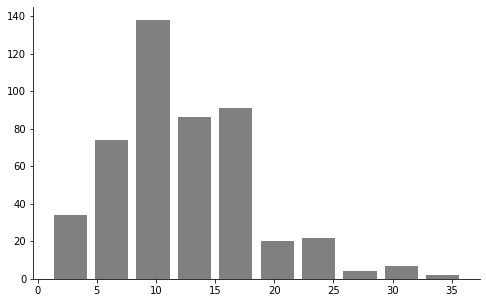

In [62]:
f, ax = plt.subplots(figsize=(8,5))
ax.hist(df_plot['family'].value_counts(), rwidth=0.8, color='grey')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_ylabel("", fontname="Arial", fontsize=20)
ax.set_xlabel("", fontname="Arial", fontsize=20)
plt.show()

In [45]:
len(df_plot['family'].unique())

478

## Heritability analysis

In [3]:
df_her = pd.read_csv('/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Gwas/data/Heritability/20221007/Heritability_summary.txt',
                   sep = '\t', header=None)
df_her = df_her.iloc[:,1:]
df_her.columns = ['Heritability', 'Se']

traitlist = pd.read_csv('/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Gwas/data/phenotype/20220822/traits.txt',sep=' ')
traitlist = list(traitlist.columns)[1:]
df_her.index = traitlist
df_her = df_her.loc[~df_her.index.isin(['PCCI', 'Std_LDCIs'])]
df_her = df_her.loc[~df_her.index.str.contains('PCCI')]
df_her.to_csv('/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Gwas/data/Heritability/20221007/Heritability.csv', sep=',')


In [5]:
##change the trait abbreviation
def trait_convert(traitlist):
    traitlist_new = []
    dic = {'DET':'TDEN', 'DEAD':'ADED', 'LTFDE':'LFDE', 'DZTD':'TDDZ'}
    for element in traitlist:
        if len(element.split('_'))==2 and element.split('_')[1] in list(dic.keys()):
            traitlist_new.append(element.replace(element.split('_')[1], dic[element.split('_')[1]]))
        elif element in list(dic.keys()):
            traitlist_new.append(element.replace(element, dic[element]))
        else:
            traitlist_new.append(element)
    return traitlist_new

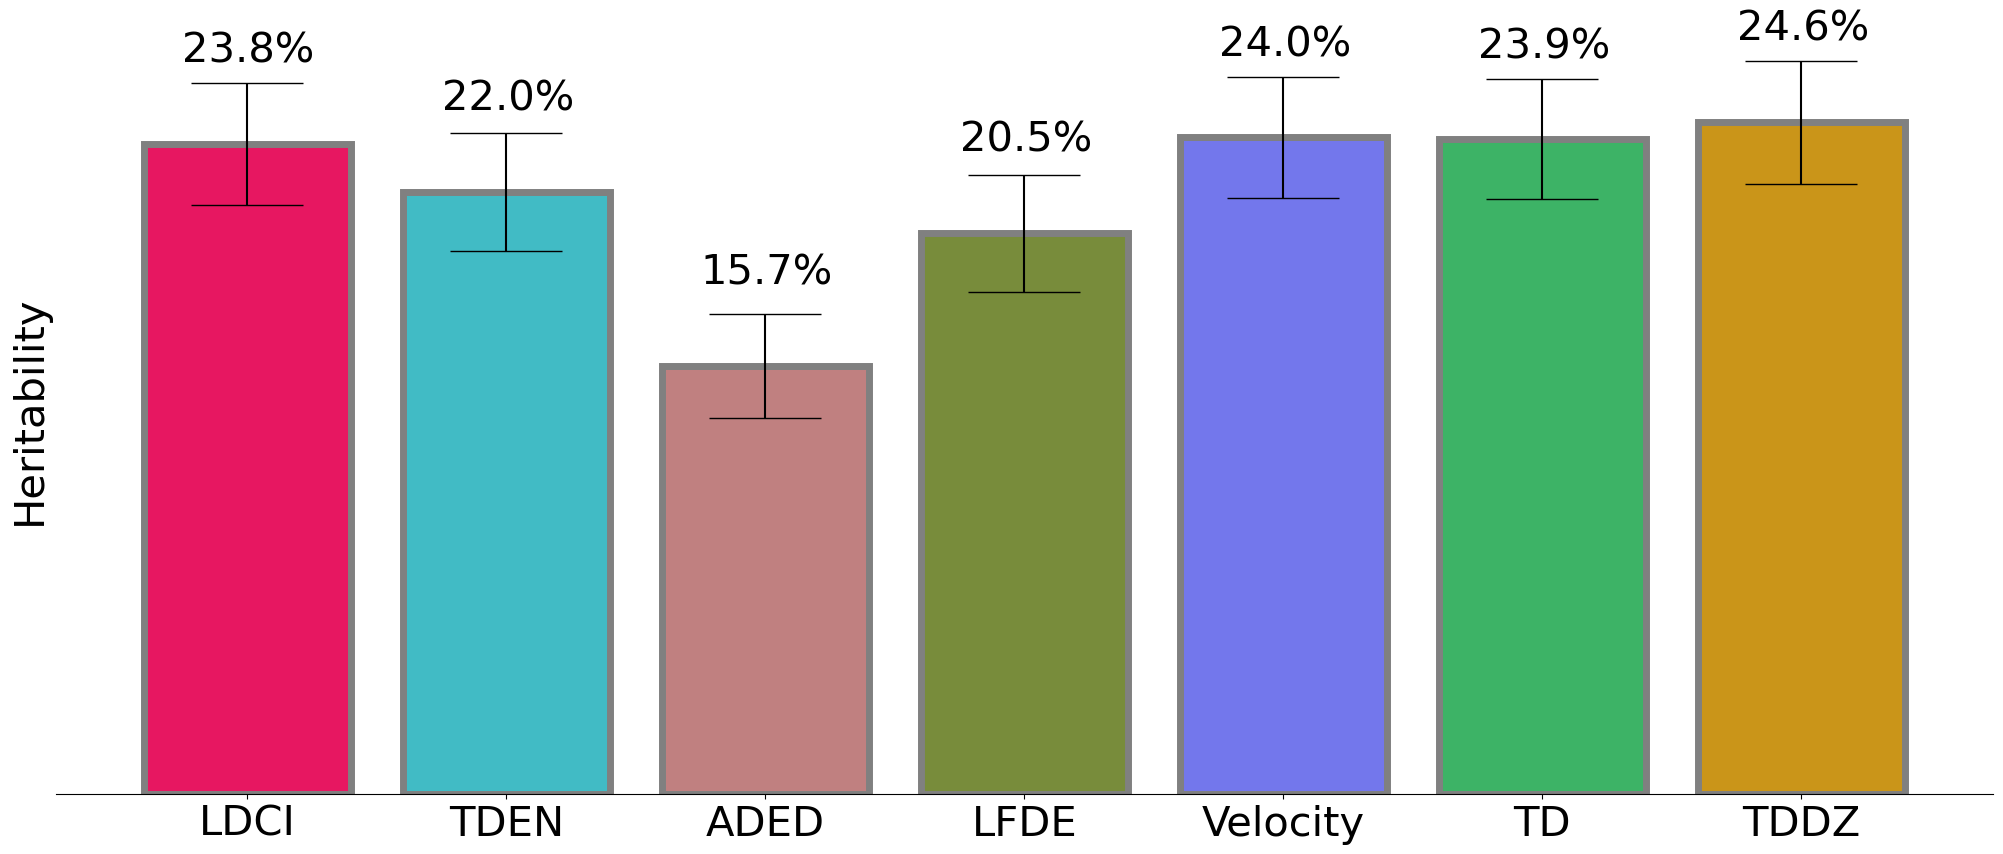

In [7]:
import matplotlib.colors as mcolors
f, ax = plt.subplots(1,1, figsize=(25,10))
df_plot = df_her.iloc[:7,:]
ax.bar(data=df_plot, x=np.arange(0,7,1),
       height=df_plot['Heritability'],yerr=df_plot['Se'], 
       capsize=40, color=["#e71761","#41bbc5", "#c08080", "#788c3b", "#7377ec", "#3db366", "#ca9519"],edgecolor='grey', linewidth=5)
ax.set_xticks(np.arange(0,7,1))
ax.set_xticklabels(trait_convert(list(df_plot.index)), size=30,horizontalalignment='center')
ax.axes.yaxis.set_ticks([])
ax.set_ylabel('Heritability',size=30)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
for i, v in enumerate(df_plot['Heritability']):
    ax.text(i-0.25,v+0.03, str(round(v*100,1))+'%', color='black', fontsize=30)
plt.savefig('/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/doc/Figures/Cell_Initial_submit/Figure 3A.tiff', format='tiff', dpi=300, bbox_inches='tight')

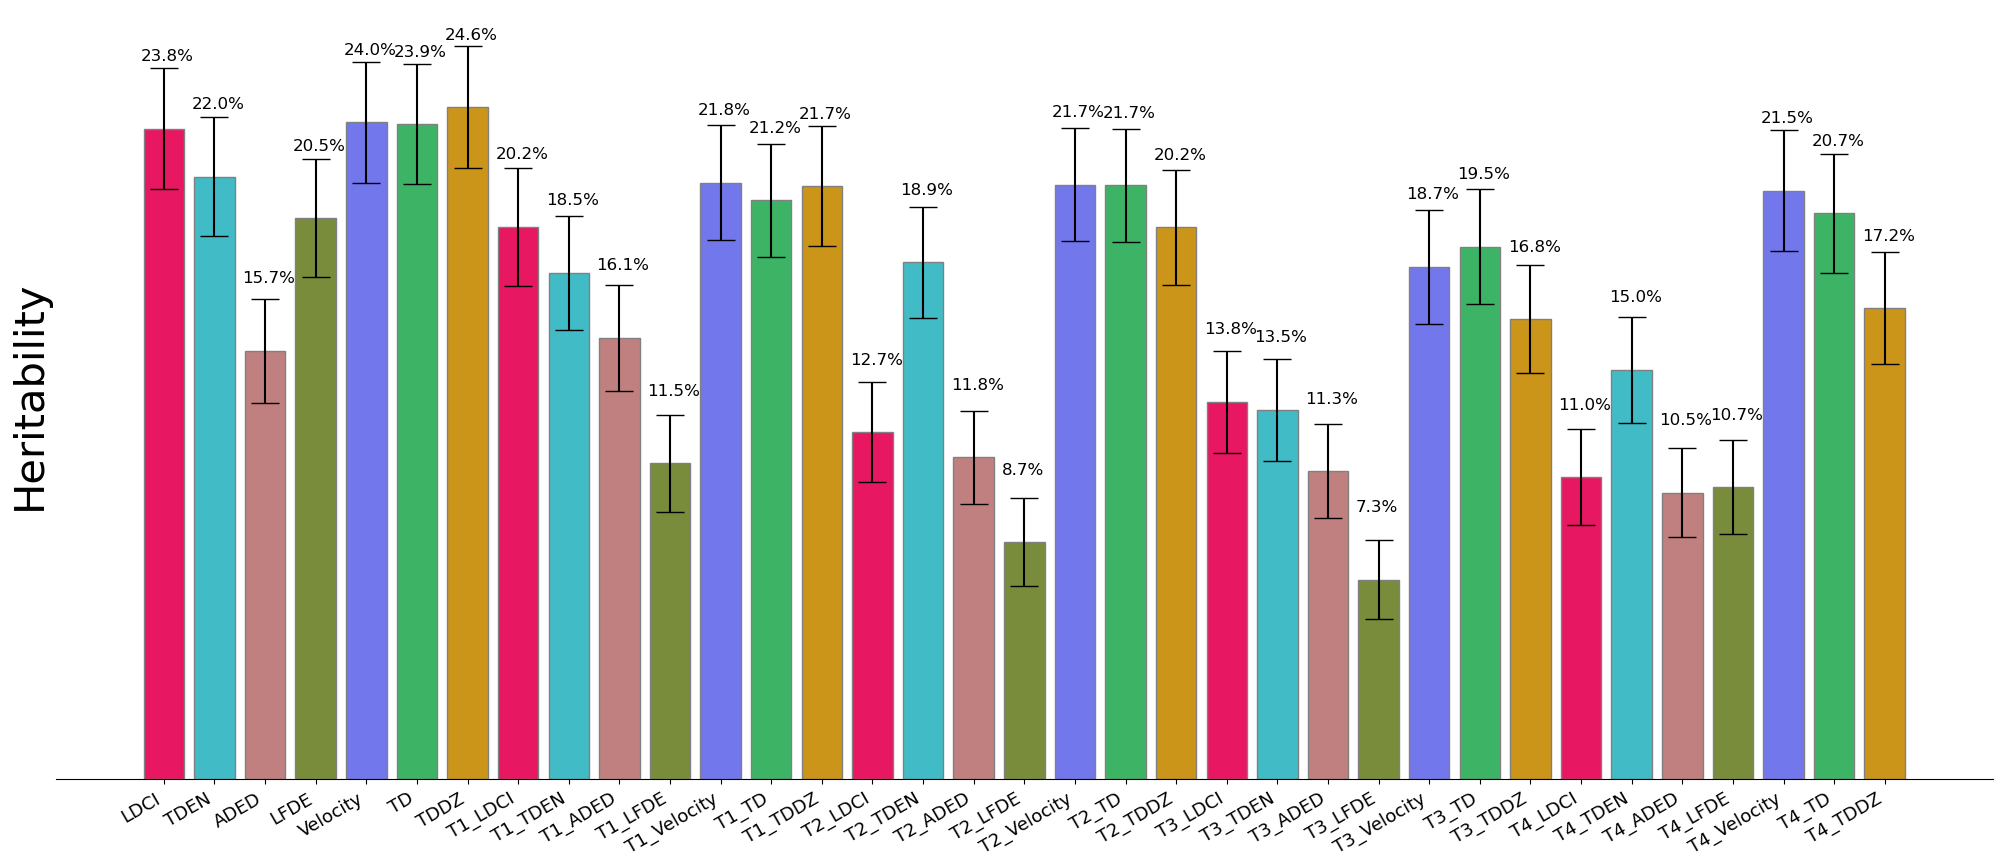

In [57]:
import matplotlib.colors as mcolors
f, ax = plt.subplots(1,1, figsize=(25,10))
df_plot = df_her.copy()
df_plot.index = trait_convert(list(df_plot.index))
trait_orders = list(df_plot.index[:7])
for i in range(1,5):
    temp_traits = ['T'+str(i)+'_'+trait for trait in list(df_plot.index[:7])]
    trait_orders = trait_orders+temp_traits
df_plot = df_plot.loc[trait_orders]
ax.bar(data=df_plot, x=np.arange(0,df_plot.shape[0],1),
       height=df_plot['Heritability'],yerr=df_plot['Se'], 
       capsize=10, color=["#e71761","#41bbc5", "#c08080", "#788c3b", "#7377ec", "#3db366", "#ca9519"],edgecolor='grey', linewidth=1)
ax.set_xticks(np.arange(0,df_plot.shape[0],1))
ax.set_xticklabels(trait_convert(list(df_plot.index)), size=13,horizontalalignment='right', rotation=30)
ax.axes.yaxis.set_ticks([])
ax.set_ylabel('Heritability',size=30)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
for i, v in enumerate(df_plot['Heritability']):
    ax.text(i-0.45,v+0.025, str(round(v*100,1))+'%', color='black', fontsize=12)
#plt.savefig('/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/doc/Figures/Cell_Initial_submit/Figure 3A.tiff', format='tiff', dpi=300, bbox_inches='tight')

### Phenotypic and genetic correlation analysis

In [73]:
input_dir = '/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Gwas/data/Heritability/20221007/hsq/'
corr_list = []
pval_list = []
for i in range(1, 9):
    for j in range(i+1, 10):
        filename = 'gc'+str(i)+'_'+str(j)+'.hsq'
        if filename in os.listdir(input_dir):
            df = pd.read_csv(input_dir+filename,sep='\t').set_index('Source')
            df['Trait1'] = str(i)
            df['Trait2'] = str(j)
            corr_list.append(df.loc['rG'])
            pval_list.append(df.loc['Pval'])
        else:
            corr_list.append(pd.Series({'Variance':np.nan, 'SE':np.nan, 'Trait1':str(i),'Trait2':str(j)}))
            pval_list.append(pd.Series({'Variance':np.nan, 'SE':np.nan, 'Trait1':str(i),'Trait2':str(j)}))
df_geno_corr = pd.concat(corr_list, axis=1).transpose()
df_geno_corr_pval = pd.concat(pval_list,axis=1).transpose()


In [63]:
df_metapheno_pro = pd.read_csv('/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Gwas/data/phenotype/20220822/metapheno_pro_20220822.txt',
                              sep = ' ', header=None)
df_gc = pd.read_csv('/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/experiments/Gwas/data/Heritability/20220614/corr_summary_20220614.txt',
                   sep = '\t', header=None)


In [67]:
df_metapheno_pro

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,20201006_Plate1_1A,1.025341,1.985944,1.583311,-0.540177,-1.874665,1.062207,1.046731,0.207407,...,2.085095,1.020575,0.186429,-0.774309,0.398156,0.365176,0.949786,0.698053,1.292804,1.401744
1,0,20201006_Plate1_1B,0.823079,-0.663028,1.469572,-0.370413,-1.169034,1.249370,1.238873,-0.026455,...,-0.534118,1.531755,0.525701,-0.794061,1.207336,1.176956,-1.038486,0.012279,1.529153,1.860516
2,0,20201006_Plate1_1C,-0.317758,1.895818,0.665981,-0.219431,-1.199124,0.065175,0.027613,-0.794614,...,1.498697,1.461308,0.101613,-1.455618,0.116630,0.034071,-0.319881,-0.575531,0.539649,-0.000632
3,0,20201006_Plate1_1D,-0.712608,1.512482,0.688306,-0.733039,-0.514216,0.435563,0.416126,-0.940411,...,2.081562,1.774319,-0.018788,-0.426766,0.246738,0.158583,-0.810201,-1.010529,0.162669,0.169214
4,0,20201006_Plate1_1E,-0.712088,0.163078,-0.936025,-0.033316,0.778054,0.156949,0.124758,-0.368254,...,1.079385,0.657944,-0.034931,0.223925,0.456956,0.387261,-0.680724,-1.908456,-0.854701,0.134522
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6146,0,20200623_Plate1_11A,NaN,-1.599239,-1.553138,NaN,2.170370,-0.053104,-0.073317,NaN,...,-1.582084,-1.893709,-2.429270,1.516292,-0.031702,-0.083838,-1.061591,-0.831675,-1.570902,NaN
6147,0,20200818_Plate1_5F,NaN,-0.857029,-1.469728,NaN,1.565203,-0.814128,-0.774309,-2.478385,...,-0.555647,-0.765086,-1.744233,1.468385,-0.258455,-0.360924,-1.490232,-1.299469,-1.205775,-0.962615
6148,0,20200818_Plate2_7F,NaN,-2.249758,-1.545102,-2.496175,1.788117,-0.390800,-0.360924,-2.429270,...,NaN,-1.063010,-1.589175,1.517566,-0.153327,-0.203341,-1.105120,-1.989234,-1.884101,-1.055234
6149,0,20201013_Plate1_5F,NaN,0.615938,-2.122457,-1.196644,1.118495,-1.316552,-1.337967,-1.438378,...,-0.537378,-0.983995,-0.530400,0.786271,-1.485351,-1.610942,-1.630444,-2.122457,-2.210947,-1.847314


In [15]:
df_corr=df_metapheno_pro.iloc[:,2:11].corr()
pheno_corr_pval = pg.pairwise_corr(df_metapheno_pro.iloc[:,2:11],padjust='bonf', method='pearson').round(3)['p-corr']


In [16]:
## extract matrix of genetic correlation coeff. and its se. 
rg = df_geno_corr['Variance']
rg

rG     0.203568
rG     0.830103
rG     0.712507
rG    -0.949606
rG     0.437243
rG     0.413758
rG     0.944784
rG     0.928937
rG     0.382814
rG    -0.067770
rG    -0.200471
rG     0.027567
rG     0.034653
rG     0.098870
rG     0.133265
rG     0.260510
rG    -0.873136
rG     0.697465
rG     0.687908
rG     0.678381
rG     0.868824
rG    -0.541170
rG    -0.085056
rG    -0.119715
rG     0.798849
rG     0.561204
rG    -0.450568
rG    -0.420065
rG    -0.824368
rG    -0.855488
rG     0.993231
0           NaN
rG     0.607940
1           NaN
rG     0.598755
rG     0.853603
Name: Variance, dtype: object

In [17]:
## extract matrix of one-tailed pairwise pval
## the column and index is the same as the column of the metaphenotype dataset
pval = df_gc.iloc[np.arange(2, 165, 3), :2]
pval['pval_one-tailed'] = pval[1].str.split('(').str[0]
pval['pval_one-tailed']=pval['pval_one-tailed'].astype('float32')
## compute two-tailed pval based on one-tailed pval
pval['pval_two-tailed']=pval['pval_one-tailed']*2
pval = pval.iloc[:, 2:]
geno_corr_pval = pval['pval_two-tailed']
geno_corr_pval

2      8.503800e-03
5      0.000000e+00
8      0.000000e+00
11     0.000000e+00
14     1.111720e-09
17     0.000000e+00
20     0.000000e+00
23     0.000000e+00
26     0.000000e+00
29     0.000000e+00
32     1.882360e-06
35     4.671200e-01
38     1.456820e-02
41     7.993200e-01
44     2.013800e-01
47     6.432200e-02
50     1.350440e-04
53     8.236600e-02
56     2.360000e-01
59     8.270600e-04
62     0.000000e+00
65     0.000000e+00
68     0.000000e+00
71     0.000000e+00
74     0.000000e+00
77     0.000000e+00
80     0.000000e+00
83     1.785540e-11
86     4.584000e-01
89     0.000000e+00
92     1.421080e-14
95     3.419400e-14
98     1.354480e-14
101    5.470400e-12
104    9.095400e-10
107    0.000000e+00
110    0.000000e+00
113    0.000000e+00
116    0.000000e+00
119    0.000000e+00
122    8.058000e-05
125    2.262000e-04
128    9.130600e-08
131    2.122200e-06
134    9.377200e-09
137    0.000000e+00
140    0.000000e+00
143    0.000000e+00
146    0.000000e+00
149    0.000000e+00


In [18]:
## convert one tail pvalue to two tail p-value
df_geno_corr_pval['pval_one-tailed'] = df_geno_corr_pval['Variance'].str.split('(').str[0]
df_geno_corr_pval['pval_one-tailed'] = df_geno_corr_pval['pval_one-tailed'].astype('float32')
## compute two-tailed pval based on one-tailed pval
df_geno_corr_pval['pval_two-tailed']=df_geno_corr_pval['pval_one-tailed']*2
geno_corr_pval = df_geno_corr_pval['pval_two-tailed']
geno_corr_pval_adj = pd.Series(pg.multicomp(geno_corr_pval,alpha=0.05,method='fdr_bh')[1])
geno_corr_pval_adj


0     1.405429e-02
1     0.000000e+00
2     0.000000e+00
3     0.000000e+00
4     4.999020e-09
5     2.550773e-08
6     0.000000e+00
7     0.000000e+00
8     2.522205e-06
9     4.729613e-01
10    2.031966e-02
11    7.288400e-01
12    6.804327e-01
13    3.181947e-01
14    1.141234e-01
15    2.906048e-03
16    0.000000e+00
17    0.000000e+00
18    0.000000e+00
19    0.000000e+00
20    0.000000e+00
21    1.318735e-10
22    3.372142e-01
23    1.719720e-01
24    0.000000e+00
25    2.417098e-12
26    5.142743e-09
27    4.486817e-08
28    0.000000e+00
29    0.000000e+00
30    0.000000e+00
31             NaN
32    0.000000e+00
33             NaN
34    0.000000e+00
35    0.000000e+00
dtype: float64

In [19]:
## combine genetic corr and phenotypic corr into one matrix

## create an upper triangle matrix with genetic corr. coeff
a= np.full((9,9),1, dtype='float32')
triu = np.triu_indices(9,1)
tril = np.tril_indices(9,-1)
a[triu]=list(rg)
## fill the lower triangle matrix with phenotypic corr. coeff
a[tril]=np.array(df_corr)[tril]

##add column and index to this combined corr. matrix 
##both the column and the index are identical to the column of metaphenotype dataset 
df_phenogeno_corr = pd.DataFrame(a)
df_phenogeno_corr.columns=df_corr.columns
df_phenogeno_corr.index = df_corr.index
df_phenogeno_corr.columns = traitlist[:9]
df_phenogeno_corr.index = traitlist[:9]
df_phenogeno_corr = df_phenogeno_corr.iloc[[0,2,3,4,5,6,8], [0,2,3,4,5,6,8]]
df_phenogeno_corr

,LDCI,DET,DEAD,LTFDE,Velocity,TD,DZTD
LDCI,1.000000,0.830103,0.712507,-0.949606,0.437243,0.413758,0.928937
DET,0.596462,1.000000,0.260510,-0.873136,0.697465,0.687908,0.868824
DEAD,0.680396,0.037949,1.000000,-0.541170,-0.085056,-0.119715,0.561204
LTFDE,-0.667399,-0.690382,-0.350374,1.000000,-0.450568,-0.420065,-0.855488
Velocity,0.276963,0.694928,-0.141114,-0.414240,1.000000,0.993231,0.607940
TD,0.269976,0.697548,-0.152178,-0.412954,0.984866,1.000000,0.598755
DZTD,0.798316,0.761375,0.328297,-0.577153,0.557182,0.560104,1.000000


In [20]:
## combine pval of genetic corr and phenotypic corr into one matrix

## create an upper triangle matrix with genetic corr. coeff
a= np.full((9,9),-1, dtype='float32')
triu = np.triu_indices(9,1)
tril = np.tril_indices(9,-1)
a[triu]=list(pheno_corr_pval)
a = a.T
a[triu]=list(geno_corr_pval_adj)

##add column and index to this combined corr. matrix 
##both the column and the index are identical to the column of metaphenotype dataset 
df_phenogeno_pval = pd.DataFrame(a)
df_phenogeno_pval.columns=df_corr.columns
df_phenogeno_pval.index = df_corr.index
df_phenogeno_pval.columns = traitlist[:9]
df_phenogeno_pval.index = traitlist[:9]
df_phenogeno_pval = df_phenogeno_pval.iloc[[0,2,3,4,5,6,8], [0,2,3,4,5,6,8]]
df_phenogeno_pval

,LDCI,DET,DEAD,LTFDE,Velocity,TD,DZTD
LDCI,-1.0,0.000,0.000000,0.000000e+00,4.999020e-09,2.550773e-08,0.000000e+00
DET,0.0,-1.000,0.002906,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
DEAD,0.0,0.109,-1.000000,1.318735e-10,3.372142e-01,1.719720e-01,2.417098e-12
LTFDE,0.0,0.000,0.000000,-1.000000e+00,5.142743e-09,4.486817e-08,0.000000e+00
Velocity,0.0,0.000,0.000000,0.000000e+00,-1.000000e+00,0.000000e+00,0.000000e+00
TD,0.0,0.000,0.000000,0.000000e+00,0.000000e+00,-1.000000e+00,0.000000e+00
DZTD,0.0,0.000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00


/Users/jialexu/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:28: UserWarning: FixedFormatter should only be used together with FixedLocator


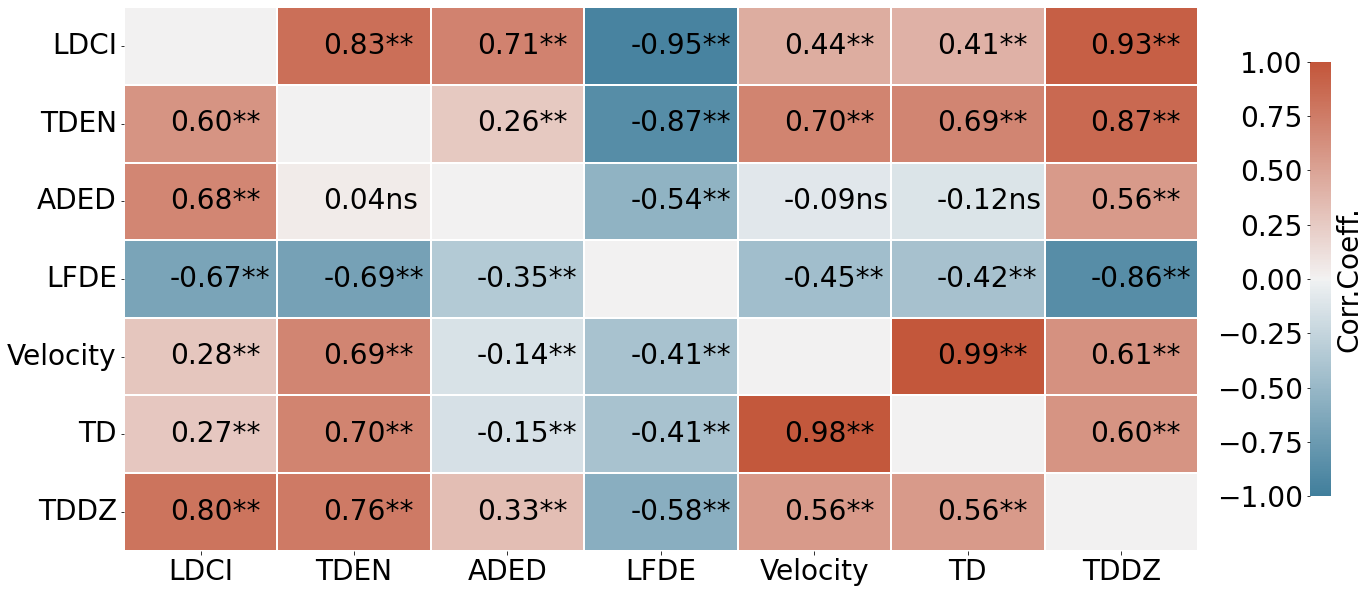

In [32]:
## plot the genetic and phenotypic correlation in a heatmap
## the color is based on the corr.coeff
## the significance is based on pval and is designated with symbol 

# make a function to convert pval to symbol to indicate significance
def annotate_pval(x):
    if x ==-1:
        return ''
    if x>0.05:
        return 'ns'
    elif x<0.05 and x >0.01:
        return '*'
    else:
        return '**'
# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap
f, ax=plt.subplots(figsize=(25,10))
labels = trait_convert(df_phenogeno_corr.columns)
fontsize = 28
sns.heatmap(df_phenogeno_corr.replace(1,0).round(2), cmap=cmap, vmax=1, vmin=-1, center=0,
            square=False, linewidths=.2, cbar_kws={"shrink": 0.8,'label':'Corr.Coeff.','pad':0.08}, \
            annot=None,annot_kws={'fontsize':12}, ax=ax)
ax.set_xticklabels(labels,rotation=0,horizontalalignment='center', fontsize=fontsize)
ax.set_yticklabels(labels,rotation=0,horizontalalignment='right',fontsize=fontsize)
ax.figure.axes[-1].yaxis.label.set_size(fontsize)
ax.figure.axes[-1].set_yticklabels(ax.figure.axes[-1].get_yticklabels(),fontsize=fontsize)
ax.figure.axes[-1].yaxis.tick_left()
for i in range(0, 7):
    for j in range (0, 7):
        pval = df_phenogeno_pval.iloc[i, j]
        
        coef = df_phenogeno_corr.replace(1,0).iloc[i,j].round(2)
        if coef == 0:
            coef = ''
        elif len(str(abs(coef)))<4:
            ax.text(j+0.3, i+0.6, str(coef)+'0'+annotate_pval(pval), fontsize=fontsize)
        else:
            ax.text(j+0.3, i+0.6, str(coef)+annotate_pval(pval), fontsize=fontsize)
plt.savefig('/Users/jialexu/Desktop/Project2GWAS-BehvaioralGenetics/doc/Figures/Cell_Initial_submit/Figure_3B.tiff', 
            format='tiff', dpi=300, bbox_inches='tight')
